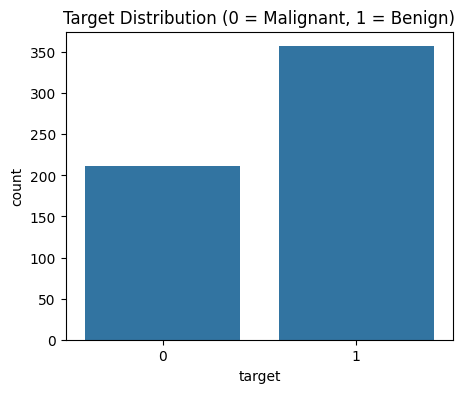


 Model Accuracy: 97.37%



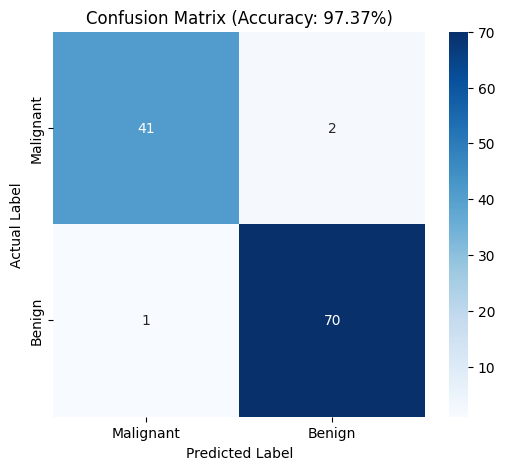

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# =========================
# Load Dataset
# =========================
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# =========================
# Visualization
# =========================
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df)
plt.title("Target Distribution (0 = Malignant, 1 = Benign)")
plt.show()

# =========================
# Split Data
# =========================
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# Feature Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# Model Training
# =========================
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# =========================
# Prediction
# =========================
y_pred = model.predict(X_test)

# =========================
# Accuracy
# =========================
acc = accuracy_score(y_test, y_pred) * 100

print("\n==============================")
print(f" Model Accuracy: {acc:.2f}%")
print("==============================\n")

# =========================
# Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant','Benign'],
            yticklabels=['Malignant','Benign'])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title(f"Confusion Matrix (Accuracy: {acc:.2f}%)")

plt.show()